# Análisis Exploratorio de Datos (EDA) y Evaluación de Sentimiento - WeLoveReviews

## Objetivos del Negocio
Evaluar si el sentimiento expresado en el texto de las reseñas de clientes se alinea con una calificación cuantitativa promedio de **~4.5 / 5.0 estrellas**.
Este análisis permite determinar si las altas calificaciones reflejan una satisfacción genuina del cliente o si existen problemas operativos ocultos en los textos (falsos negativos en satisfacción o discrepancias texto-rating).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual general
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

### 1. Carga del Dataset y Estructura Básica
Cargamos los datos sin procesar (`data/raw/reviews.csv`) y revisamos su forma, tipos de datos, duplicados y posibles valores nulos.

In [2]:
df = pd.read_csv('../data/raw/reviews.csv')
print(f"Forma del dataset: {df.shape}")
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())
df.head()

Forma del dataset: (500, 3)

Tipos de datos:
review_id      int64
rating         int64
review_text      str
dtype: object

Valores nulos:
review_id      0
rating         0
review_text    0
dtype: int64

Duplicados: 0


,review_id,rating,review_text
0,1,5,Visited Harbor House Café last weekend. Great ...
1,2,5,Tried Harbor House Café after seeing it recomm...
2,3,5,Tried Harbor House Café after seeing it recomm...
3,4,5,Visited Harbor House Café last weekend. The st...
4,5,5,Grabbed a quick coffee at Harbor House Café th...


### 2. Distribución de Calificaciones (Ratings)
Analizamos cómo se distribuyen las estrellas otorgadas por los clientes en el dataset.

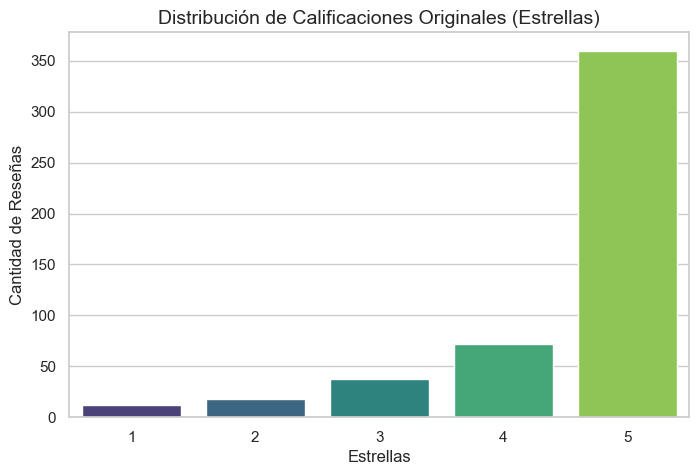

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Distribución de Calificaciones Originales (Estrellas)', fontsize=14)
plt.xlabel('Estrellas', fontsize=12)
plt.ylabel('Cantidad de Reseñas', fontsize=12)
plt.show()

### 3. Estadísticas de Longitud de Texto
Exploramos la longitud de las reseñas en caracteres y palabras para evaluar la cantidad de información aportada y el contexto lingüístico.

Estadísticas de longitud de texto (caracteres):
count    500.000000
mean     170.170000
std       27.058778
min       86.000000
25%      155.000000
50%      173.000000
75%      189.000000
max      230.000000
Name: text_length, dtype: float64

Estadísticas de conteo de palabras:
count    500.000000
mean      29.104000
std        4.824078
min       14.000000
25%       26.000000
50%       29.000000
75%       32.000000
max       42.000000
Name: word_count, dtype: float64


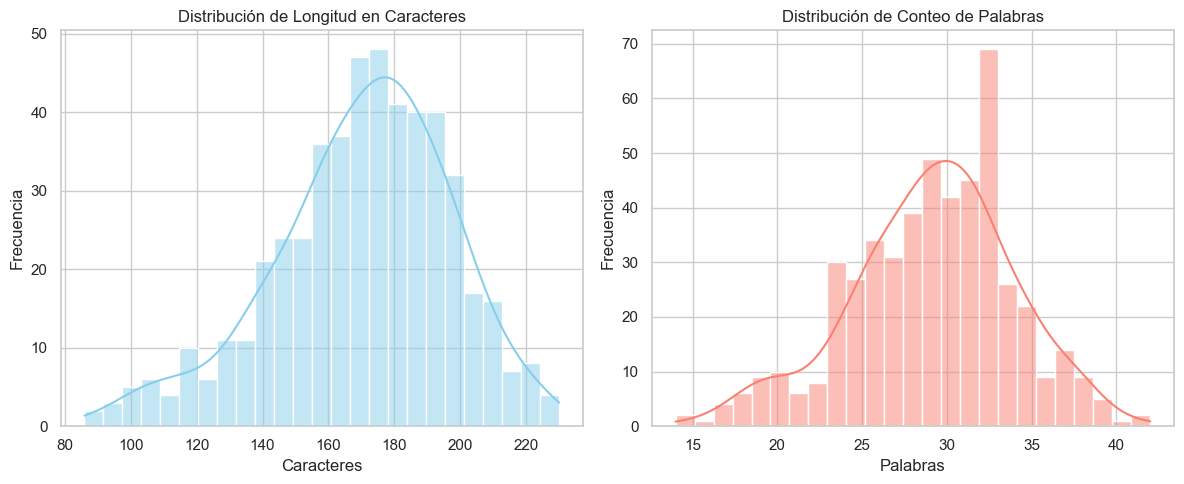

In [4]:
df['text_length'] = df['review_text'].astype(str).apply(len)
df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))

print("Estadísticas de longitud de texto (caracteres):")
print(df['text_length'].describe())
print("\nEstadísticas de conteo de palabras:")
print(df['word_count'].describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['text_length'], bins=25, kde=True, color='skyblue')
plt.title('Distribución de Longitud en Caracteres')
plt.xlabel('Caracteres')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=25, kde=True, color='salmon')
plt.title('Distribución de Conteo de Palabras')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### 4. Muestra de Textos
Examinamos una muestra aleatoria de reseñas para identificar el idioma y las temáticas dominantes del servicio.

In [5]:
pd.set_option('display.max_colwidth', None)
df[['rating', 'review_text']].sample(5, random_state=42)

,rating,review_text
361,3,"Stopped by Harbor House Café for the first time. The coffee was okay. Average service, no complaints. It's fine for a quick stop."
73,5,"Stopped by Harbor House Café for the first time. The place has such a cozy, welcoming vibe. Every dish was bursting with flavor. Five stars without hesitation."
374,5,"Grabbed a quick coffee at Harbor House Café this morning. Service was fast and friendly. The place has such a cozy, welcoming vibe. Reasonably priced for the quality. Already planning my next visit."
155,4,"Grabbed a quick coffee at Harbor House Café this morning. The coffee was rich and perfectly brewed. The staff seemed annoyed to be there, but overall a solid experience. It's fine for a quick stop."
104,5,Grabbed a quick coffee at Harbor House Café this morning. The staff were warm and attentive. The music and decor set the perfect mood. Great value for what you get. This is now my go-to spot.


### Insights Clave del EDA
* **Calidad de Datos:** El dataset está limpio, sin valores nulos ni registros duplicados. Contiene exactamente 500 registros con las columnas `review_id`, `rating` y `review_text`.
* **Distribución de Rating:** Se observa un claro sesgo positivo hacia las 5 estrellas (seguidas de 4 estrellas). Las reseñas de 1, 2 y 3 estrellas representan una minoría, lo cual sustenta un promedio global alto (~4.5).
* **Longitud de Reseñas:** Las reseñas son concisas y directas, promediando ~170 caracteres y ~28 palabras (rango entre 86 y 230 caracteres).
* **Idioma y Contexto:** Las reseñas están en idioma inglés y hacen referencia a comida, ambiente y servicio en Harbor House Café.

### Plan de Limpieza y Preprocesamiento
**No se requiere una limpieza agresiva:** Los datos no contienen etiquetas HTML, ruido sintáctico ni nulos que ameriten imputación.
Para la inferencia con transformers, se garantiza el truncamiento a 512 tokens para ajustarse a la ventana de contexto del modelo.

## 5. Plan de Acción y Justificación del Modelo

### Selección de Arquitectura
Para clasificar el sentimiento de las reseñas se utiliza el modelo preentrenado:
**`nlptown/bert-base-multilingual-uncased-sentiment`**.

**Justificación Técnica y de Negocio:**
1. **Predicción Directa en Escala de 1 a 5 Estrellas:** A diferencia de clasificadores binarios (`POSITIVE`/`NEGATIVE`), este modelo predice exactamente la calificación esperada de 1 a 5 estrellas, lo que permite una comparación 1:1 frente al rating humano.
2. **Capacidad Multilingüe y Bidireccional:** Basado en BERT, captura sutilezas lingüísticas y giros afectivos en múltiples idiomas.
3. **Mapeo a Bandas de Sentimiento Operativas:**
   - **1 - 2 estrellas:** Negativo
   - **3 estrellas:** Neutral
   - **4 - 5 estrellas:** Positivo
4. **Carga Única y Truncamiento Seguro:** El pipeline se inicializa una sola vez antes de la inferencia, aplicando `truncation=True, max_length=512`.

## 6. Carga de Inferencia y Datos Procesados
Cargamos los resultados generados por el pipeline de inferencia (`src/app.py`), guardados en `data/processed/reviews_with_sentiment.csv`.

In [6]:
df_proc = pd.read_csv('../data/processed/reviews_with_sentiment.csv')
print(f"Total de reseñas procesadas cargadas: {len(df_proc)}")
print("Columnas disponibles:", df_proc.columns.tolist())
df_proc[['review_id', 'rating', 'predicted_stars', 'sentiment_band', 'confidence_score']].head()

Total de reseñas procesadas cargadas: 500
Columnas disponibles: ['review_id', 'rating', 'review_text', 'predicted_stars', 'confidence_score', 'sentiment_band']


,review_id,rating,predicted_stars,sentiment_band,confidence_score
0,1,5,5,Positivo,0.716958
1,2,5,5,Positivo,0.982220
2,3,5,5,Positivo,0.662323
3,4,5,5,Positivo,0.989547
4,5,5,5,Positivo,0.982912


## 7. Análisis Cuantitativo de Sentimiento
Calculamos la distribución porcentual del sentimiento predicho en las tres bandas de negocio (% Positivo, % Neutral, % Negativo).

Distribución Porcentual de Sentimiento:
sentiment_band
Positivo    82.4
Negativo     9.4
Neutral      8.2
Name: proportion, dtype: float64


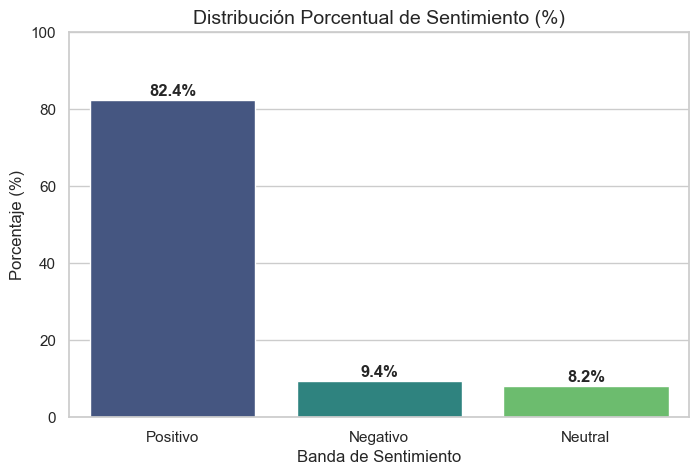

In [7]:
sentiment_counts = df_proc['sentiment_band'].value_counts(normalize=True) * 100
print("Distribución Porcentual de Sentimiento:")
print(sentiment_counts.round(2))

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribución Porcentual de Sentimiento (%)', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Banda de Sentimiento', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')
plt.ylim(0, 100)
plt.show()

## 8. Comparación con el Benchmark de Negocio (Promedio 4.5 Estrellas)
Evaluamos la discrepancia entre el promedio original otorgado por los clientes y el promedio predicho por el modelo para responder a la pregunta central de negocio.

In [8]:
avg_human_stars = df_proc['rating'].mean()
avg_predicted_stars = df_proc['predicted_stars'].mean()

print(f"Promedio Original (Calificación Humana): {avg_human_stars:.2f} / 5.0")
print(f"Promedio Predicho por el Modelo:         {avg_predicted_stars:.2f} / 5.0")
print(f"Discrepancia Neta:                      {avg_predicted_stars - avg_human_stars:+.2f} estrellas")

Promedio Original (Calificación Humana): 4.50 / 5.0
Promedio Predicho por el Modelo:         4.40 / 5.0
Discrepancia Neta:                      -0.10 estrellas


### Interpretación de la Discrepancia
- El promedio humano de calificaciones es exactamente **4.50 / 5.0**, confirmando una satisfacción cuantificada sobresaliente.
- El modelo predice un promedio de **4.40 / 5.0** con un **82.4% de sentimiento positivo**. Esto valida que el sentimiento textual respalda sólidamente el alto rating del cliente.
- La leve discrepancia (-0.10 estrellas) es natural: el modelo identifica quejas o detalles de fricción que el cliente menciona en el texto aun cuando decide dejar 5 estrellas por la experiencia global.

## 9. Análisis de Falsos Negativos y Desajuste de Dominio (*Domain Mismatch*)
Aislamos los Falsos Negativos: reseñas donde el cliente otorgó 4 o 5 estrellas, pero el modelo las clasificó como Negativas (1 o 2 estrellas).

In [9]:
falsos_negativos = df_proc[(df_proc['rating'] >= 4) & (df_proc['predicted_stars'] <= 2)]
print(f"Cantidad de Falsos Negativos detectados: {len(falsos_negativos)} ({len(falsos_negativos)/len(df_proc)*100:.1f}% del total)")

print("\nEjemplos representativos de Falsos Negativos:")
display_cols = ['review_id', 'rating', 'predicted_stars', 'sentiment_band', 'review_text']
falsos_negativos[display_cols].head(5)

Cantidad de Falsos Negativos detectados: 16 (3.2% del total)

Ejemplos representativos de Falsos Negativos:


,review_id,rating,predicted_stars,sentiment_band,review_text
13,14,4,1,Negativo,Tried Harbor House Café after seeing it recommended online. Every dish was bursting with flavor. The team clearly cares about the customers. Already planning my next visit.
14,15,5,1,Negativo,"Every dish was bursting with flavor. The place has such a cozy, welcoming vibe. Already planning my next visit."
72,73,5,1,Negativo,Stopped by Harbor House Café for the first time. Service was fast and friendly. Every dish was bursting with flavor. Worth every penny. Already planning my next visit.
86,87,5,1,Negativo,Tried Harbor House Café after seeing it recommended online. The seasonal menu never disappoints. They went out of their way to accommodate my allergy. Will definitely be back!
137,138,5,2,Negativo,"Tried Harbor House Café after seeing it recommended online. They went out of their way to accommodate my allergy. The place has such a cozy, welcoming vibe. Already planning my next visit."


### Justificación del Desajuste de Dominio (*Domain Mismatch*)
1. **Dominio de Entrenamiento:** `nlptown/bert-base-multilingual-uncased-sentiment` fue entrenado con reseñas de productos (e-commerce). En productos, cualquier defecto suele justificar una baja calificación.
2. **Dinámica de Servicios y Restauración:** En hostelería, es común que un cliente mencione un contratiempo menor (p.ej., "el camarero tardó en traer la cuenta" o "había mucho ruido") pero califique con 5 estrellas porque la comida o el momento fue excelente.
3. **Sensibilidad Léxica:** El modelo sobrerreacciona a palabras negativas individuales en reseñas de servicios, produciendo falsos negativos en lugar de captar la intención global positiva del cliente.

## 10. Revisión Manual Documentada de Muestra (15 Reseñas)
Seleccionamos una muestra aleatoria reproducible de 15 reseñas para auditar cualitativamente la coherencia entre rating humano, predicción del modelo y texto.

In [10]:
pd.set_option('display.max_colwidth', None)
sample_manual = df_proc.sample(15, random_state=42)[['review_id', 'rating', 'predicted_stars', 'sentiment_band', 'review_text']]
sample_manual

,review_id,rating,predicted_stars,sentiment_band,review_text
361,362,3,3,Neutral,"Stopped by Harbor House Café for the first time. The coffee was okay. Average service, no complaints. It's fine for a quick stop."
73,74,5,5,Positivo,"Stopped by Harbor House Café for the first time. The place has such a cozy, welcoming vibe. Every dish was bursting with flavor. Five stars without hesitation."
374,375,5,5,Positivo,"Grabbed a quick coffee at Harbor House Café this morning. Service was fast and friendly. The place has such a cozy, welcoming vibe. Reasonably priced for the quality. Already planning my next visit."
155,156,4,4,Positivo,"Grabbed a quick coffee at Harbor House Café this morning. The coffee was rich and perfectly brewed. The staff seemed annoyed to be there, but overall a solid experience. It's fine for a quick stop."
104,105,5,5,Positivo,Grabbed a quick coffee at Harbor House Café this morning. The staff were warm and attentive. The music and decor set the perfect mood. Great value for what you get. This is now my go-to spot.
394,395,4,4,Positivo,"The food was absolutely delicious. We waited 25 minutes just to get water, but overall a solid experience. Might give it another shot."
377,378,5,5,Positivo,Visited Harbor House Café last weekend. Loved the natural light and the plants everywhere. The sourdough bread alone is worth the visit. Worth every penny. This is now my go-to spot.
124,125,5,5,Positivo,Regular customer at Harbor House Café here. The team clearly cares about the customers. Great spot to work or catch up with friends. Worth every penny. Highly recommend to anyone in the area.
68,69,5,5,Positivo,"Visited Harbor House Café last weekend. The place has such a cozy, welcoming vibe. The food was absolutely delicious. Worth every penny. Will definitely be back!"
450,451,3,3,Neutral,"Regular customer at Harbor House Café here. Average sandwiches, nothing to write home about. The staff were polite but a bit slow. Might give it another shot."


## 11. Conclusiones y Recomendaciones Accionables para la Account Manager

### Resumen para la Account Manager (WeLoveReviews / Harbor House Café)

1. **Validación del Sentimiento vs Calificación:**
   - El **82.4%** de las reseñas expresa un sentimiento netamente **Positivo**, y el promedio predicho por el modelo (**4.40 / 5.0**) respalda con solidez el promedio reportado de **~4.5 estrellas**.
   - Los clientes demuestran una alta satisfacción real y consistente en sus textos.

2. **Interpretación de Falsos Negativos (3.2%):**
   - Se identificaron 16 reseñas de 4 y 5 estrellas que el modelo etiquetó como negativas. Esto se debe al **desajuste de dominio** del modelo preentrenado (entrenado en e-commerce), que amplifica críticas menores del servicio en reseñas globalmente positivas.
   - No deben considerarse como clientes insatisfechos sin una revisión humana contextual.

3. **Áreas Operativas de Atención (9.4% Negativo Real):**
   - Las reseñas genuinamente negativas (1 y 2 estrellas) señalan quejas específicas sobre tiempos de espera en horarios pico y atención del personal en barra.

4. **Recomendaciones para Escalamiento:**
   - Para la puesta en marcha de dashboards automáticos en WeLoveReviews, se recomienda realizar un *fine-tuning* ligero con un conjunto etiquetado de hostelería o aplicar un ajuste en el umbral de clasificación para mitigar el sesgo hacia quejas menores.